In [ ]:
#pip install sounddevice

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [sounddevice] [cffi]
Note: you may need to restart the kernel to use updated packages.


# Sound of the diatonic scales

In [117]:
import numpy as np
import sounddevice as sd
import matplotlib.pyplot as plt
"""
def play_tone(freq, duration=1.0, sample_rate=44100):
    t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)
    wave = 0.2 * np.sin(2 * np.pi * freq * t)#+0.01 * np.sin(2 * np.pi * freq * t * 2)#+0.001 * np.sin(2 * np.pi * freq * t * 3)
    sd.play(wave, sample_rate)
    sd.wait()
"""
def play_tone(freq, duration=1.0, sample_rate=44100):
    t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)

    # Harmonic amplitudes (roughly violin/guitar-like)
    harmonics = [
        (1, 1.00),
        (2, 0.2),
        (3, 0.25),
        (4, 0.125),
        (5, 0.05),
        (6, 0.025),
        (7, 0.0125),
        (8, 0.005),
    ]

    wave = np.zeros_like(t)

    for n, amp in harmonics:
        wave += amp * np.sin(2 * np.pi * n * freq * t)

    # ADSR-like envelope
    attack = 0.01      # 10 ms
    decay = 0.10       # 100 ms
    sustain = 0.7
    release = 0.20     # last 20% of note

    envelope = np.ones_like(t)

    a = int(attack * sample_rate)
    d = int(decay * sample_rate)
    r = int(release * len(t))

    # Attack
    envelope[:a] = np.linspace(0, 1, a)

    # Decay
    envelope[a:a+d] = np.linspace(1, sustain, d)

    # Release
    envelope[-r:] *= np.linspace(sustain, 0, r)

    wave *= envelope

    # Normalize to avoid clipping
    wave /= np.max(np.abs(wave))

    sd.play(0.25 * wave, sample_rate)
    sd.wait()

play_tone(440)   # A4

In [126]:
f0 = 440
Pythagorean =np.array([1, 9/8, 81/64, 4/3, 3/2, 27/16, 242/128,2])

Just = np.array([1, 9/8, 5/4, 4/3, 3/2, 5/3, 15/8,2])

r = np.power(2, 1/12)

Equal = np.array([1, r**2, r**4, r**5, r**7, r**9, r**11, r**12])

for i in range(8):
    play_tone(Pythagorean[i]*f0)

for i in range(8):
    play_tone(Just[i]*f0)

for i in range(8):
    play_tone(Equal[i]*f0)

KeyboardInterrupt: 

In [ ]:
for i in range(8):
    play_tone(Pythagorean[i]*f0)
    play_tone(Just[i]*f0)
    play_tone(Equal[i]*f0)

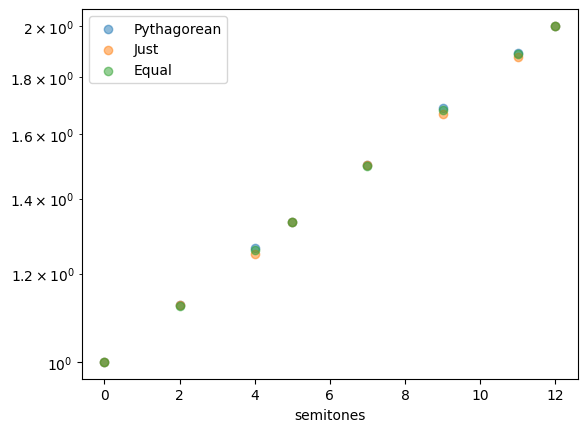

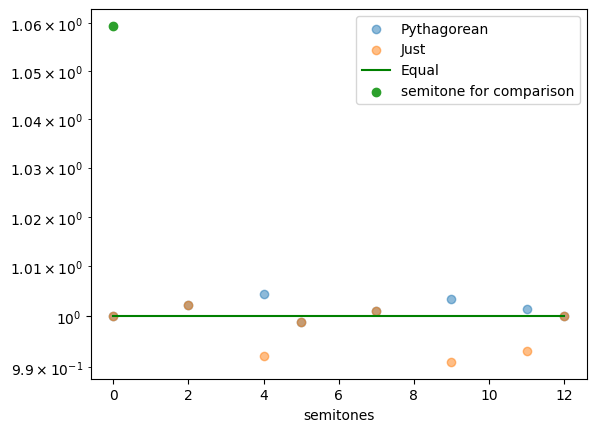

In [135]:
semitones = [0,2,4,5,7,9,11,12]
plt.scatter(semitones, Pythagorean, label="Pythagorean",alpha=0.5)
plt.scatter(semitones, Just, label="Just",alpha=0.5)
plt.scatter(semitones, Equal,label="Equal",alpha=0.5)
plt.xlabel("semitones")
plt.legend()

plt.yscale("log")
plt.show()

plt.scatter(semitones, Pythagorean/Equal, label="Pythagorean", alpha=0.5)
plt.scatter(semitones, Just/Equal, label="Just", alpha=0.5)
plt.plot(semitones, Equal/Equal, color="green", 
        label="Equal")
plt.scatter([0],[np.power(2,1/12)], label="semitone for comparison")
plt.yscale("log")
plt.xlabel("semitones")
plt.legend()

### Unpleasant major third in Pythagorean tuning

In [38]:

def play_two (ratio, freq=440, duration=1.0, sample_rate=44100):

    t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)
    wave = 0.2 * np.sin(2 * np.pi * freq * t) + 0.2 * np.sin(2 * np.pi * freq * t * ratio)
    sd.play(wave, sample_rate)
    sd.wait()

play_two(81/64)

#### Same major third in Just tuning

In [39]:
play_two(5/4)

#### Same major third in equal temperatment 

In [40]:
play_two(np.power(2,4/12))

In [ ]:
## All three
play_two(81/64)
play_two(5/4)
play_two(np.power(2,4/12))

In [37]:
## Pyth major third and fifth
play_two(81/64)
play_two(3/2)
## Just major third and fifth
play_two(5/4)
play_two(3/2)
## equal temperament major third and fifth
play_two(r**4)
play_two(r**7)

## Try more realistic overtones

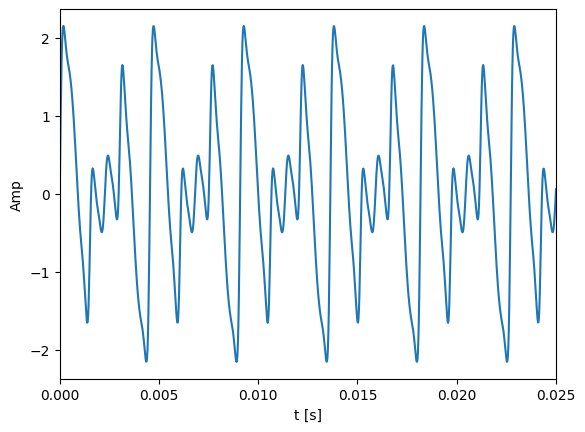

In [109]:
def play_tone_flute_ratio(freq, ratio=1, duration=1.0, sample_rate=44100, plot=False, title=""):
    t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)

    # Harmonic amplitudes (roughly violin/guitar-like)
    harmonics = [
        (1, 1.00),
        (2, 0.25),
        (3, 0.25),
        (4, 0.125),
        (5, 0.05),
        (6, 0.025),
        (7, 0.0125),
        (8, 0.005),
    ]

    wave = np.zeros_like(t)

    for n, amp in harmonics:
        wave += amp * np.sin(2 * np.pi * n * freq * t) + amp * np.sin(2 * np.pi * n * freq * t*ratio)

    if plot:
        plt.plot(t, wave)
        plt.xlabel("t [s]")
        plt.ylabel("Amp")
        plt.xlim(0,2.5e-2)
        plt.title(title)
        plt.show()
    # ADSR-like envelope
    attack = 0.01      # 10 ms
    decay = 0.10       # 100 ms
    sustain = 0.7
    release = 0.20     # last 20% of note

    envelope = np.ones_like(t)

    a = int(attack * sample_rate)
    d = int(decay * sample_rate)
    r = int(release * len(t))

    # Attack
    envelope[:a] = np.linspace(0, 1, a)

    # Decay
    envelope[a:a+d] = np.linspace(1, sustain, d)

    # Release
    envelope[-r:] *= np.linspace(sustain, 0, r)

    wave *= envelope

    # Normalize to avoid clipping
    wave /= np.max(np.abs(wave))

    sd.play(0.25 * wave, sample_rate)
    sd.wait()

play_tone_flute_ratio(440,3/2, plot=True)

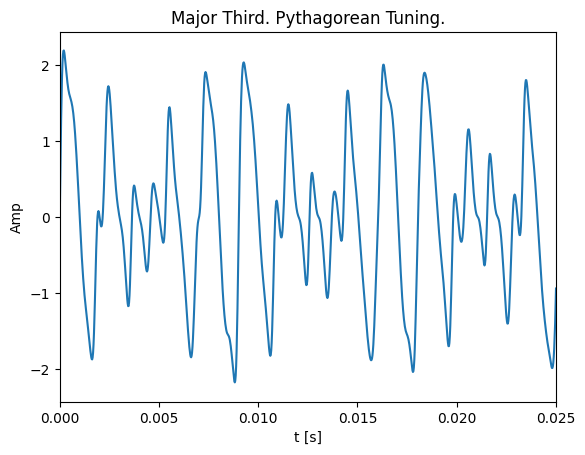

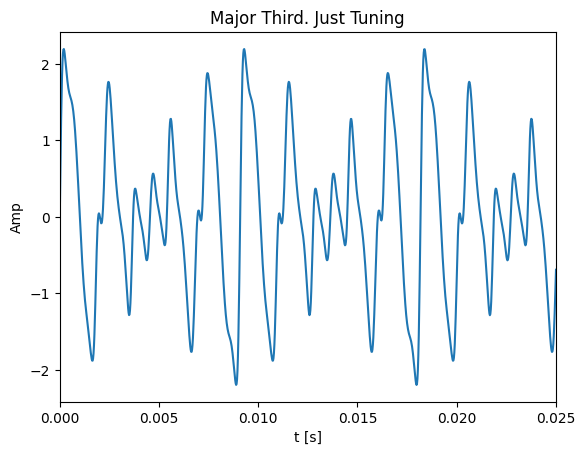

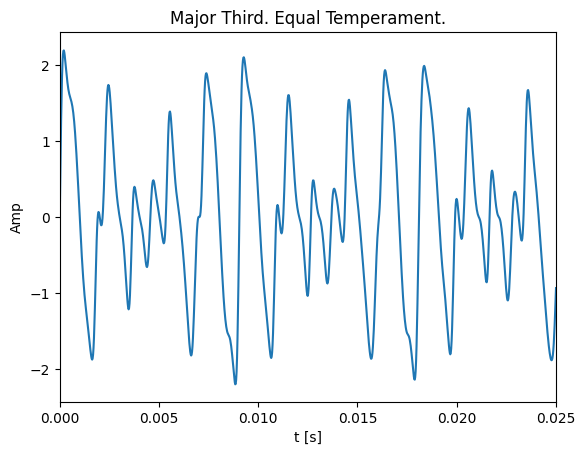

In [113]:
## All three
play_tone_flute_ratio(440,81/64,plot=True, title="Major Third. Pythagorean Tuning.")
play_tone_flute_ratio(440,5/4,plot=True, title="Major Third. Just Tuning")
play_tone_flute_ratio(440,np.power(2,4/12),plot=True, title="Major Third. Equal Temperament.")

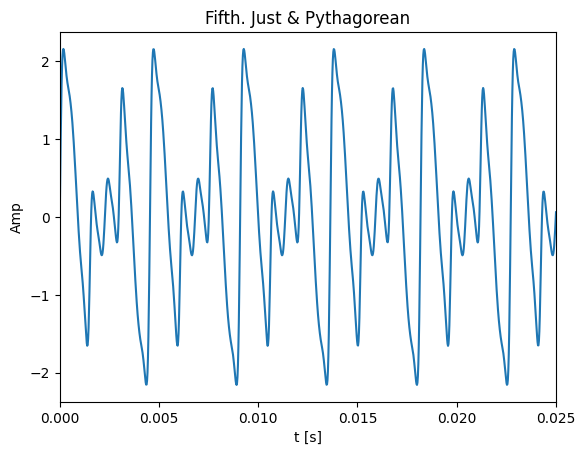

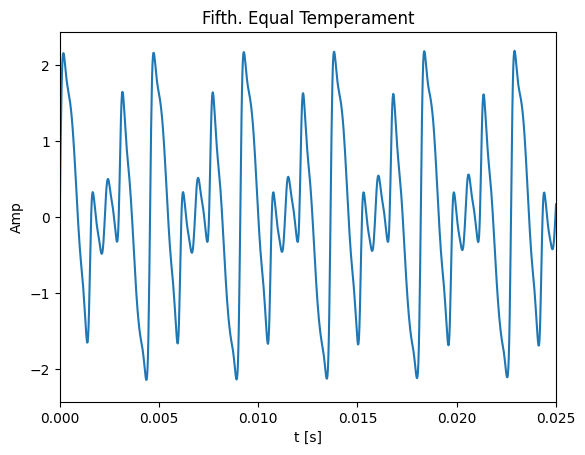

In [111]:
play_tone_flute_ratio(440,3/2,plot=True,title="Fifth. Just & Pythagorean")
play_tone_flute_ratio(440,np.power(2,7/12),plot=True, title="Fifth. Equal Temperament")